In [ ]:
library(readxl)


df <- read_excel("Secundario_adultos_limpio.xlsx")

# Contar el número de NAs por fila
na_por_columna <- colSums(is.na(df))

# Mostrar el conteo de NAs por fila
print(na_por_columna)
head(df)
table(df$Asignatura)

                 CUE          institucion         departamento 
                   0                    0                    0 
           EsPrivada          anioLectivo                curso 
                   0                    0                    0 
           Documento           Asignatura  NotaPrimerTrimestre 
                   0                    0                    0 
NotaSegundoTrimestre  NotaTercerTrimestre        NotaDiciembre 
                   0                    0                 1301 
            Promedio             Aprobado   ResultadoDiciembre 
                   0                    0                    0 


CUE,institucion,departamento,EsPrivada,anioLectivo,curso,Documento,Asignatura,NotaPrimerTrimestre,NotaSegundoTrimestre,NotaTercerTrimestre,NotaDiciembre,Promedio,Aprobado,ResultadoDiciembre
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,HISTORIA,3,1,1,NA,1.666667,Reprobo promedio,Reprobo(no se presento a mesa)
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,GEOGRAFIA,4,1,1,NA,2.000000,Reprobo promedio,Reprobo(no se presento a mesa)
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,LENGUA Y LITERATURA,5,4,4,NA,4.333333,Reprobo promedio,Reprobo(no se presento a mesa)
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,MATEMATICA,4,4,3,NA,3.666667,Reprobo promedio,Reprobo(no se presento a mesa)
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22174024,LENGUA Y LITERATURA,8,9,10,NA,9.000000,Aprobado,Aprobado en cursada
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22174024,HISTORIA,9,10,10,NA,9.666667,Aprobado,Aprobado en cursada



          GEOGRAFIA            HISTORIA LENGUA Y LITERATURA LENGUAS EXTRANJERAS 
                277                 294                 292                 257 
         MATEMATICA 
                295 

In [ ]:
install.packages("rstatix")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘corrplot’




In [ ]:
library(dplyr)

# Create the new 'resultado_final' column based on 'Aprobado' and 'ResultadoDiciembre'
# Proposed conditions based on observed values:
df <- df %>%
  mutate(resultado_final = case_when(
    Aprobado == "Aprobado" ~ "Aprobado",
    Aprobado == "Reprobo promedio" &  ResultadoDiciembre == c("Reprobo en mesa", "Reprobo(no se presento a mesa)")  ~ "Reprobado",
    Aprobado == "Reprobo tercer trimestre" &  ResultadoDiciembre == c("Reprobo en mesa", "Reprobo(no se presento a mesa)")   ~ "Reprobado", # Assuming reprobar tercer trimestre leads to reprobado final
    ResultadoDiciembre %in% c("Reprobo en mesa", "Reprobo(no se presento a mesa)") ~ "Reprobado",
    ResultadoDiciembre %in% c("Aprobado en mesa", "Aprobado en cursada") ~ "Aprobado",
    TRUE ~ "Otro" # Default for any other case not explicitly covered
  ))

# Display the first few rows with the new column
df_otro <- df %>% filter(resultado_final == "Otro")
head(df)
# Optional: Check the distribution of the new column
table(df$resultado_final)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `resultado_final = case_when(...)`.
Caused by warning in `ResultadoDiciembre == c("Reprobo en mesa", "Reprobo(no se presento a mesa)")`:
! longer object length is not a multiple of shorter object length
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


CUE,institucion,departamento,EsPrivada,anioLectivo,curso,Documento,Asignatura,NotaPrimerTrimestre,NotaSegundoTrimestre,NotaTercerTrimestre,NotaDiciembre,Promedio,Aprobado,ResultadoDiciembre,resultado_final
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,HISTORIA,3,1,1,NA,1.666667,Reprobo promedio,Reprobo(no se presento a mesa),Reprobado
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,GEOGRAFIA,4,1,1,NA,2.000000,Reprobo promedio,Reprobo(no se presento a mesa),Reprobado
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,LENGUA Y LITERATURA,5,4,4,NA,4.333333,Reprobo promedio,Reprobo(no se presento a mesa),Reprobado
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,MATEMATICA,4,4,3,NA,3.666667,Reprobo promedio,Reprobo(no se presento a mesa),Reprobado
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22174024,LENGUA Y LITERATURA,8,9,10,NA,9.000000,Aprobado,Aprobado en cursada,Aprobado
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22174024,HISTORIA,9,10,10,NA,9.666667,Aprobado,Aprobado en cursada,Aprobado



 Aprobado Reprobado 
      780       635 

In [ ]:
table(df$NotaTercerTrimestre)
table(df$EsPrivada)

table(df$curso)
table(df$institucion)


  1   2   3   4   5   6   7   8   9  10 
 46   4 147 348 147 107 126 167 203 120 


   N 
1415 


Año 1 de 3-Secundaria Año 2 de 3-Secundaria Año 3 de 3-Secundaria 
                  500                   414                   501 


                               E.S.J.A. N° 41 PEDRO GOYENA 
                                                      1003 
ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE 
                                                       292 
   ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 5 RAUL SOLDI 
                                                       120 

[1] "Conteo de registros por curso (dataframe completo):"
# A tibble: 3 × 3
  curso                 Cantidad Frecuencia_Relativa
  <chr>                    <int>               <dbl>
1 Año 1 de 3-Secundaria      500                35.3
2 Año 2 de 3-Secundaria      414                29.3
3 Año 3 de 3-Secundaria      501                35.4


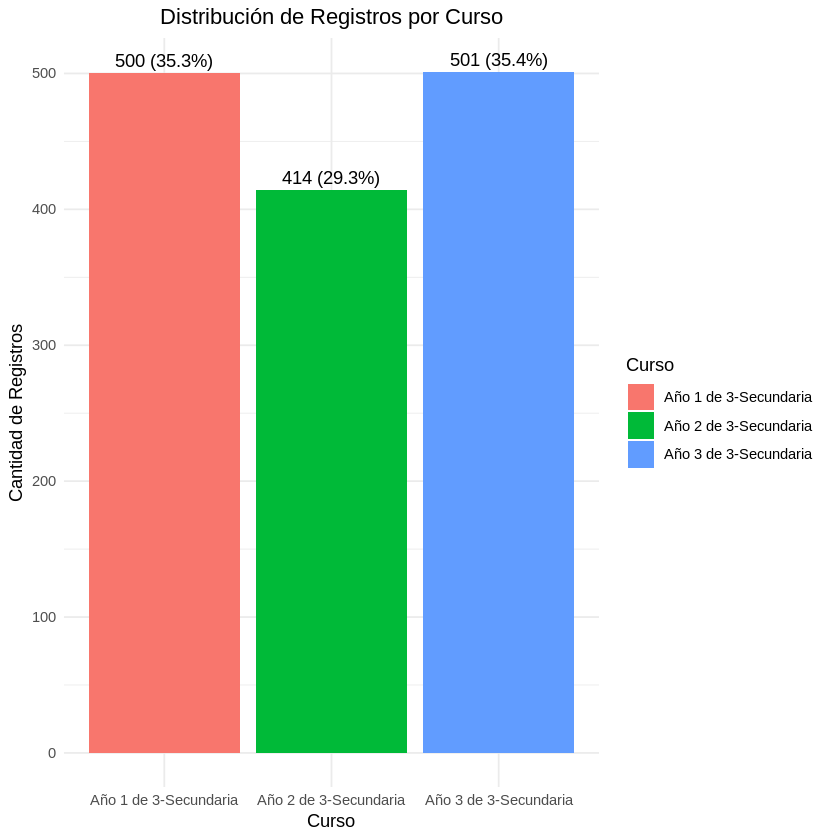

In [ ]:
library(dplyr)
library(ggplot2)

# Asegúrate de que df esté disponible y sea un dataframe
if (!is.data.frame(df)) {
  print("df no es un dataframe o no existe.")
} else {

  # Contar la cantidad de registros por curso
  conteo_por_curso_total <- df %>%
    group_by(curso) %>%
    summarise(Cantidad = n()) %>%
    mutate(Frecuencia_Relativa = Cantidad / sum(Cantidad) * 100)

  # Imprimir el conteo para verificar
  print("Conteo de registros por curso (dataframe completo):")
  print(conteo_por_curso_total)

  # Crear el gráfico de barras de registros
  ggplot(conteo_por_curso_total, aes(x = curso, y = Cantidad, fill = curso)) +
    geom_bar(stat = "identity") +
    geom_text(aes(label = paste0(Cantidad, " (", round(Frecuencia_Relativa, 1), "%)")),
              vjust = -0.5) + # Ajustar posición del texto
    labs(title = "Distribución de Registros por Curso",
         x = "Curso",
         y = "Cantidad de Registros",
         fill = "Curso") +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5)) # Centrar el título

}

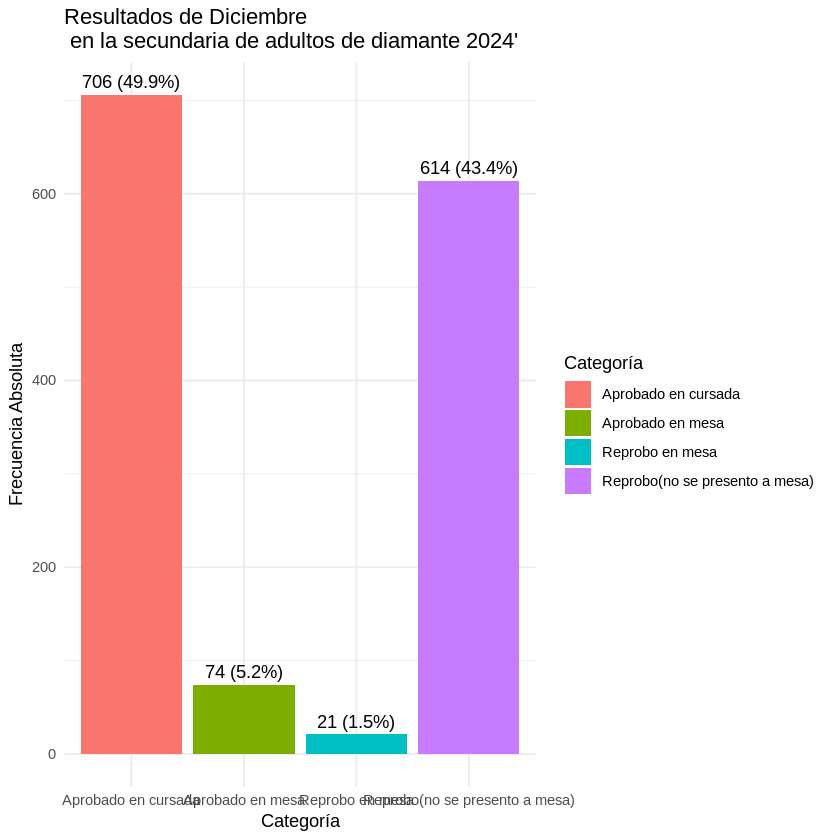

In [ ]:
# Instalar y cargar la librería necesaria para gráficos
if (!require("ggplot2")) install.packages("ggplot2")
library(ggplot2)



# Calcular las frecuencias absolutas y relativas
tabla <- table(df$ResultadoDiciembre)
tabla_relativa <- prop.table(tabla) * 100

# Crear un data frame para el gráfico
datos_grafico <- data.frame(
  categoria = names(tabla),
  frecuencia_absoluta = as.vector(tabla),
  frecuencia_relativa = as.vector(tabla_relativa)
)

# Crear el gráfico de barras
ggplot(datos_grafico, aes(x = categoria, y = frecuencia_absoluta, fill = categoria)) +
  geom_col() + # Usar geom_col() para barras
  geom_text(aes(label = paste0(frecuencia_absoluta, " (", round(frecuencia_relativa, 1), "%)")),
            vjust = -0.5) +  # Ajustar posición del texto
  labs(title = "Resultados de Diciembre \n en la secundaria de adultos de diamante 2024'",
       x = "Categoría",
       y = "Frecuencia Absoluta",
       fill = "Categoría") +
  theme_minimal() # usar un tema diferente si se desea


In [ ]:
library(dplyr)

df_matematica <- df %>% filter(Asignatura == "MATEMATICA")

In [ ]:
# Asegúrate de tener cargada la librería dplyr
# library(dplyr)

df_matematica <- df_matematica %>%
  mutate(resultado_final = case_when(
    ResultadoDiciembre %in% c("Aprobado en mesa", "Aprobado en cursada") ~ "Aprobado",
    ResultadoDiciembre %in% c("Reprobo en mesa", "Reprobo(no se presento a mesa)") ~ "Reprobado",
    TRUE ~ ResultadoDiciembre # Mantener otros valores si los hay
  ))



`summarise()` has grouped output by 'curso'. You can override using the
`.groups` argument.


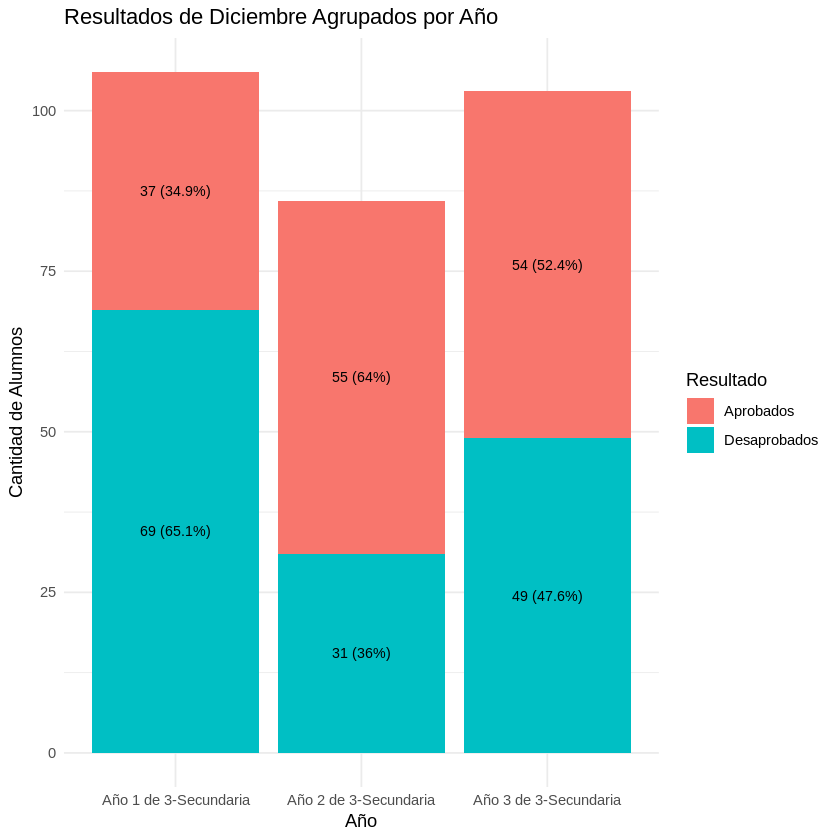

In [ ]:
# Instalar y cargar las librerías necesarias
if (!require("ggplot2")) install.packages("ggplot2")
if (!require("dplyr")) install.packages("dplyr")

library(ggplot2)
library(dplyr)

# Agrupar los resultados en "Aprobados" y "Desaprobados"
df_barras_apiladas <- df_matematica %>%
  mutate(ResultadoAgrupado = case_when(
    resultado_final %in% c("Aprobado") ~ "Aprobados",
    resultado_final %in% c("Reprobado") ~ "Desaprobados",
    TRUE ~ "Otro" # Para cualquier otro caso no contemplado
  ))

# Crear un dataframe con los resultados agrupados y frecuencias por curso para el gráfico único
df_agrupado_total <- df_barras_apiladas %>%
  group_by(curso, ResultadoAgrupado) %>%
  summarise(Cantidad = n()) %>%
  mutate(Frecuencia_Relativa = Cantidad / sum(Cantidad) * 100)

# Crear el gráfico de barras apiladas único para todos los cursos
ggplot(df_agrupado_total, aes(x = curso, y = Cantidad, fill = ResultadoAgrupado)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = paste0(Cantidad, " (", round(Frecuencia_Relativa, 1), "%)")),
            position = position_stack(vjust = 0.5), size = 3) +
  labs(title = "Resultados de Diciembre Agrupados por Año",
       x = "Año",
       y = "Cantidad de Alumnos",
       fill = "Resultado") +
  theme_minimal()

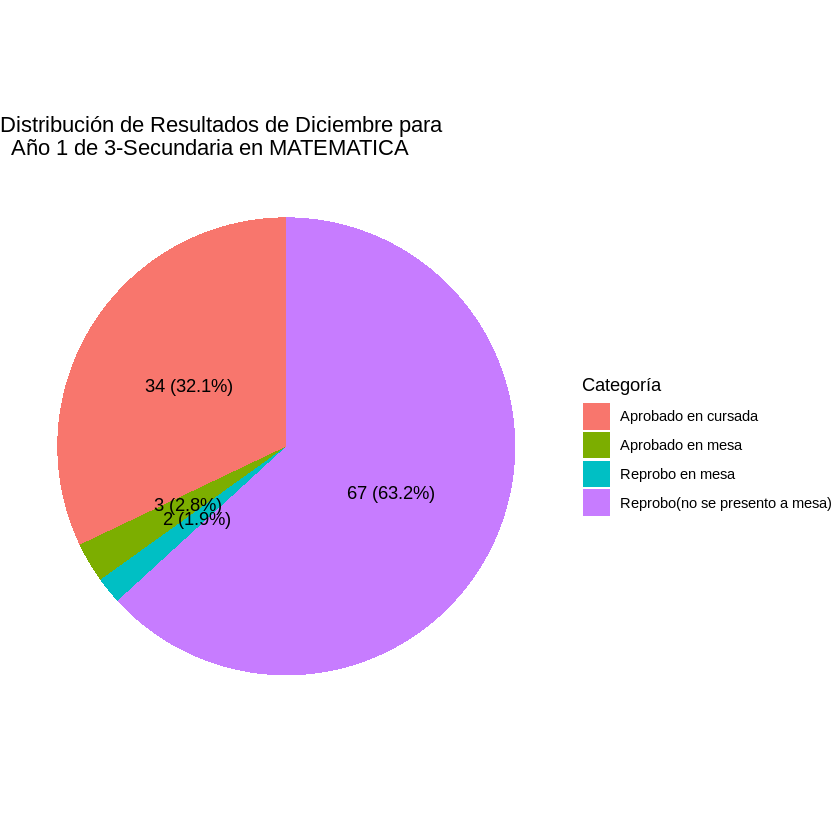

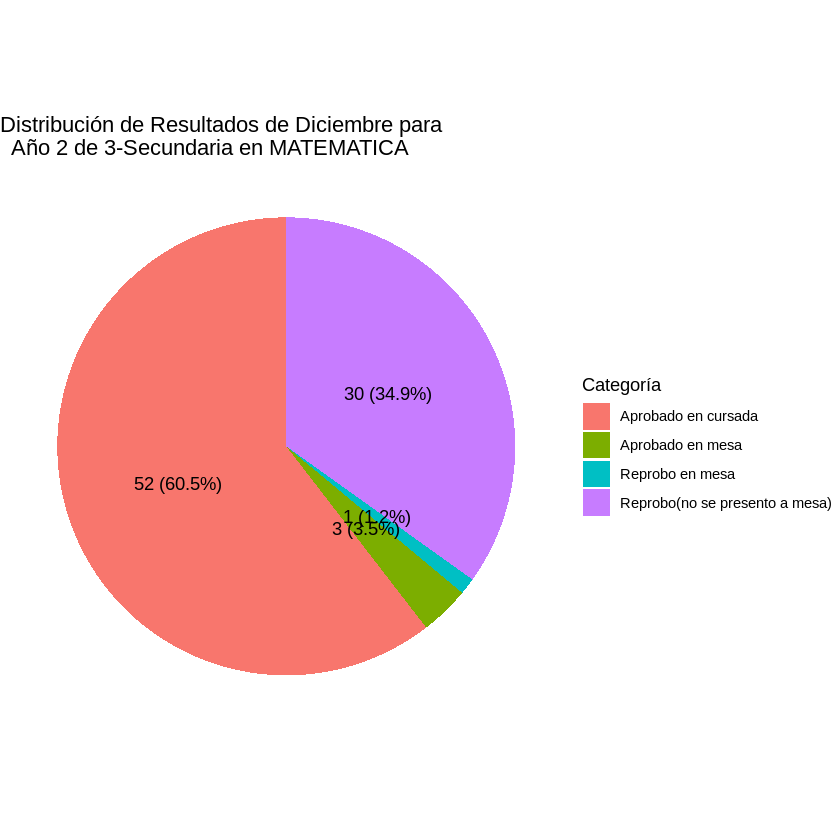

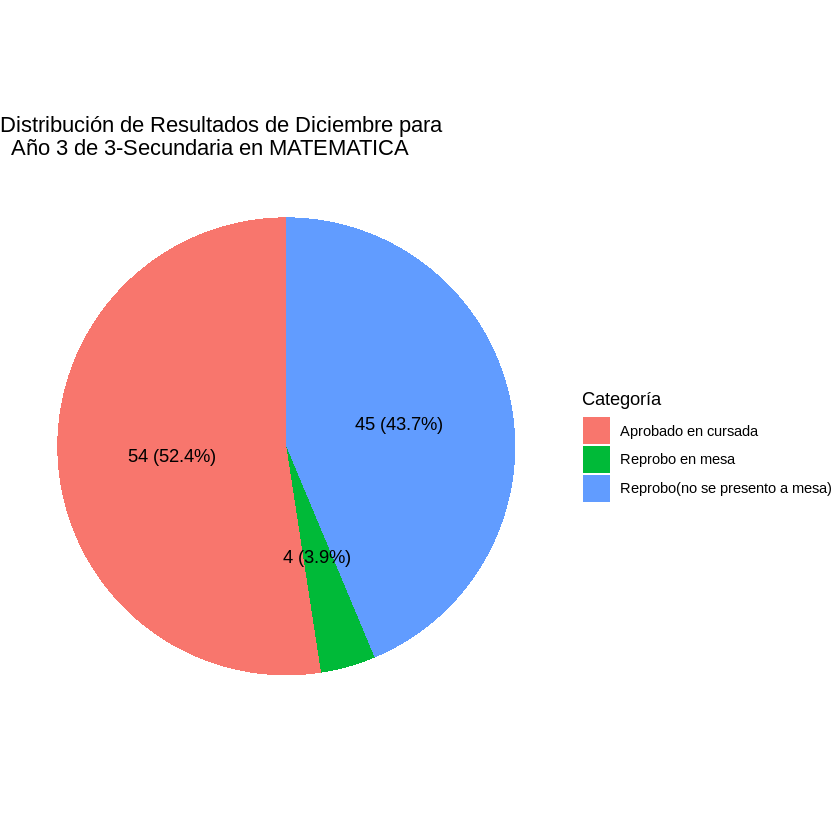

In [ ]:
# Ensure df is a data frame in R if it's not already
if (!is.data.frame(df)) {
  df <- as.data.frame(df)
}

# Instalar y cargar la librería necesaria para gráficos
if (!require("ggplot2")) install.packages("ggplot2")
library(ggplot2)

# Función para crear el gráfico de torta para un curso y materia específicos
crear_grafico_torta <- function(curso_seleccionado, materia_seleccionada) {
  # Filtrar los datos para el curso y materia seleccionados
  df_curso_materia <- df[df$curso == curso_seleccionado & df$Asignatura == materia_seleccionada, ]

  # Check if the filtered dataframe is empty
  if (nrow(df_curso_materia) == 0) {
    print(paste("No data available for", curso_seleccionado, "in", materia_seleccionada))
    return(NULL) # Return NULL if no data
  }

  # Calcular la tabla de frecuencias para 'ResultadoDiciembre'
  tabla <- table(df_curso_materia$ResultadoDiciembre)

  # Crear un data frame para el gráfico
  datos_grafico <- data.frame(
    categoria = names(tabla),
    frecuencia_absoluta = as.vector(tabla) # Store absolute frequency
  )

  # Calcular la frecuencia relativa
  datos_grafico$frecuencia_relativa <- datos_grafico$frecuencia_absoluta / sum(datos_grafico$frecuencia_absoluta) * 100

  # Crear el gráfico de torta
  ggplot(datos_grafico, aes(x = "", y = frecuencia_absoluta, fill = categoria)) + # Use absolute frequency for the y-axis
    geom_bar(stat = "identity", width = 1) +
    coord_polar("y", start = 0) +
    geom_text(aes(label = paste0(frecuencia_absoluta, " (", round(frecuencia_relativa, 1), "%)")), # Combine absolute and relative frequency in the label
              position = position_stack(vjust = 0.5)) +
    labs(title = paste("Distribución de Resultados de Diciembre para \n ", curso_seleccionado, "en", materia_seleccionada),
         fill = "Categoría") +
    theme_void()
}

# Crear los gráficos de torta para cada curso en "MATEMATICA"
grafico_torta_año1_matematica <- crear_grafico_torta("Año 1 de 3-Secundaria", "MATEMATICA")
grafico_torta_año2_matematica <- crear_grafico_torta("Año 2 de 3-Secundaria", "MATEMATICA")
grafico_torta_año3_matematica <- crear_grafico_torta("Año 3 de 3-Secundaria", "MATEMATICA")

# Mostrar los gráficos de torta (only if they are not NULL)
if (!is.null(grafico_torta_año1_matematica)) print(grafico_torta_año1_matematica)
if (!is.null(grafico_torta_año2_matematica)) print(grafico_torta_año2_matematica)
if (!is.null(grafico_torta_año3_matematica)) print(grafico_torta_año3_matematica)

In [ ]:
library(dplyr)


# Asegúrate de que las variables sean factores si aún no lo son (aunque no es estrictamente necesario para chisq.test)
df_matematica$resultado_final <- as.factor(df_matematica$resultado_final)
df_matematica$curso <- as.factor(df_matematica$curso)

# Crear la tabla de contingencia
tabla_contingencia <- table(df_matematica$curso, df_matematica$resultado_final)

# Mostrar la tabla de contingencia
print("Tabla de Contingencia (Aprobado vs. anioLectivo):")
print(tabla_contingencia)

# Aplicar el test de Chi-cuadrado
cat("\n--- Resultados del Test de Chi-cuadrado ---\n")
chi <- chisq.test(tabla_contingencia)
chi
round(chi$residuals, 1)

[1] "Tabla de Contingencia (Aprobado vs. anioLectivo):"
                       
                        Aprobado Reprobado
  Año 1 de 3-Secundaria       37        69
  Año 2 de 3-Secundaria       55        31
  Año 3 de 3-Secundaria       54        49

--- Resultados del Test de Chi-cuadrado ---



	Pearson's Chi-squared test

data:  tabla_contingencia
X-squared = 16.572, df = 2, p-value = 0.000252


                       
                        Aprobado Reprobado
  Año 1 de 3-Secundaria     -2.1       2.1
  Año 2 de 3-Secundaria      1.9      -1.9
  Año 3 de 3-Secundaria      0.4      -0.4

Los nuevos residuos, junto con el valor p significativo del test de Chi-cuadrado, sugieren que la asociación significativa entre el resultado final y el año del curso se debe principalmente a las desviaciones observadas en el Año 1 y el Año 2.

El Año 1 tiene ligeramente menos aprobados y más reprobados de lo que se esperaría.
El Año 2 tiene un poco más de aprobados y menos reprobados de lo que se esperaría.
El Año 3 se comporta de manera muy similar a lo esperado bajo independencia y no parece contribuir significativamente a la asociación global encontrada por el test.
Por lo tanto, basado en estos residuos, podríamos decir que hay una diferencia significativa en las proporciones de aprobado/reprobado entre el Año 1 y el Año 3, y entre el Año 2 y el Año 3. La diferencia entre el Año 1 y el Año 2 también contribuye a la significancia global. El Año 3 es el que menos se desvía del patrón esperado.

Es una interpretación diferente a la anterior debido a los cambios en los datos, donde ahora las desviaciones más fuertes se observan en el Año 1 y Año 2, mientras que el Año 3 muestra un comportamiento más cercano a la independencia.

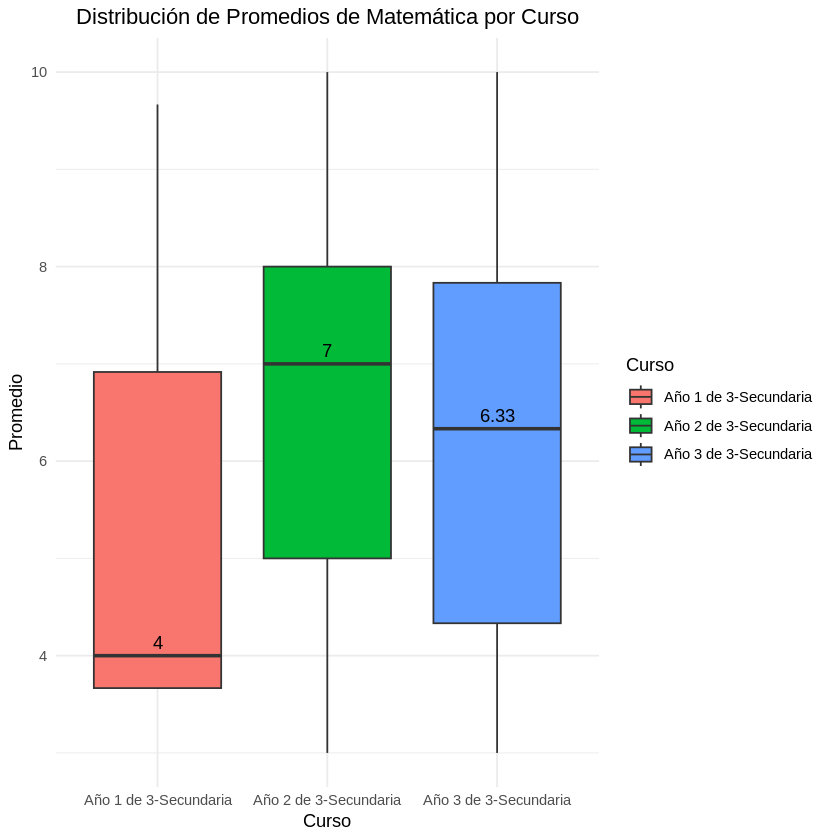

In [ ]:
library(dplyr)
library(ggplot2)

# Asegúrate de que df_matematica esté disponible y sea un dataframe, o filtra df
if (!exists("df_matematica") || !is.data.frame(df_matematica)) {
  print("Creando df_matematica filtrando df por Asignatura == 'MATEMATICA'")
  if (!is.data.frame(df)) {
     print("df no es un dataframe o no existe. No se puede filtrar.")
  } else {
     df_matematica <- df %>% filter(Asignatura == "MATEMATICA")
  }
}

medianas_m <- df %>%
  group_by(curso) %>%
  summarise(mediana = median(Promedio))


# Verificar si df_matematica se creó correctamente
if (exists("df_matematica") && is.data.frame(df_matematica)) {

  # Crear los box plots de los promedios por curso en df_matematica
  ggplot(df_matematica, aes(x = curso, y = Promedio, fill = curso)) +
    geom_boxplot() +
    geom_text(data = medianas_m, aes(x = curso, y = mediana, label = round(mediana, 2)),
            vjust = -0.5, color = "black") +
    labs(title = "Distribución de Promedios de Matemática por Curso",
         x = "Curso",
         y = "Promedio",
         fill = "Curso") +
    theme_minimal() +
    theme(plot.title = element_text(hjust = 0.5)) # Centrar el título

} else {
  print("No se pudo crear o encontrar el dataframe df_matematica para generar el gráfico.")
}

**Reasoning**:
Perform the Chi-squared test on the contingency table and print the results.



# Task
Realice un gráfico de perfiles que compare las notas de materias troncales de primer año por sector. Compare los vectores de medias, y establezca a través de un test de hipótesis si hay diferencias significativas.

## Preparación de los datos

### Subtask:
Filtrar el dataframe para incluir solo los datos del primer año (`Año 1 de 3-Secundaria`) y las materias troncales relevantes.


**Reasoning**:
Filter the dataframe to include only the first year and the relevant core subjects as instructed in the subtask.



In [ ]:
library(dplyr)


# Filter for relevant core subjects
materias_troncales <- c("MATEMATICA", "LENGUA Y LITERATURA", "HISTORIA", "GEOGRAFIA", "LENGUAS EXTRANJERAS")
df_primer_año_troncales <- df %>% filter(Asignatura %in% materias_troncales)

# Display the first few rows of the filtered dataframe
head(df_primer_año_troncales)

CUE,institucion,departamento,EsPrivada,anioLectivo,curso,Documento,Asignatura,NotaPrimerTrimestre,NotaSegundoTrimestre,NotaTercerTrimestre,NotaDiciembre,Promedio,Aprobado,ResultadoDiciembre,resultado_final
<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,HISTORIA,3,1,1,NA,1.666667,Reprobo promedio,Reprobo(no se presento a mesa),Reprobado
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,GEOGRAFIA,4,1,1,NA,2.000000,Reprobo promedio,Reprobo(no se presento a mesa),Reprobado
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,LENGUA Y LITERATURA,5,4,4,NA,4.333333,Reprobo promedio,Reprobo(no se presento a mesa),Reprobado
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22006316,MATEMATICA,4,4,3,NA,3.666667,Reprobo promedio,Reprobo(no se presento a mesa),Reprobado
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22174024,LENGUA Y LITERATURA,8,9,10,NA,9.000000,Aprobado,Aprobado en cursada,Aprobado
6000268,ESCUELA SECUNDARIA DE JÓVENES Y ADULTOS N° 2 30 DE OCTUBRE,DIAMANTE,N,2024,Año 1 de 3-Secundaria,22174024,HISTORIA,9,10,10,NA,9.666667,Aprobado,Aprobado en cursada,Aprobado


In [ ]:
if (!require("car")) install.packages("car")

Loading required package: car

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘car’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘cowplot’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’




In [ ]:
library(dplyr)
library(car) # For Levene's test (optional but recommended)
library(ggplot2) # For visualizations (optional)

# Ensure 'df' is available and contains the necessary columns
if (!exists("df") || !is.data.frame(df)) {
  stop("El dataframe 'df' no existe.")
}

# Define core subjects
materias_troncales <- c("MATEMATICA", "HISTORIA")

# Filter the dataframe for core subjects
df_troncales <- df %>%
  filter(Asignatura %in% materias_troncales)

# Perform ANOVA for each core subject and store the results
anova_results <- list()
for (materia in materias_troncales) {
  # Filter data for the current subject
  df_materia <- df_troncales %>%
    filter(Asignatura == materia)

  # Check if there is enough data for ANOVA
  if (nrow(df_materia) < 3 || length(unique(df_materia$curso)) < 2) {
    print(paste("No hay suficientes datos para realizar ANOVA para", materia))
    next
  }

  # Perform the one-way ANOVA test
  anova_result <- aov(Promedio ~ curso, data = df_materia)
  anova_results[[materia]] <- anova_result # Store the ANOVA result
}

# Perform normality test on residuals for Matematica and Historia
subjects_to_test_normality <- c("MATEMATICA", "HISTORIA")

for (materia in subjects_to_test_normality) {
  if (!is.null(anova_results[[materia]])) {
    cat("\n--- Test de Normalidad (Shapiro-Wilk) para los residuos de ANOVA de", materia, "---\n")
    residuals <- residuals(anova_results[[materia]])
    shapiro_test_result <- shapiro.test(residuals)
    print(shapiro_test_result)

    # Interpret the results
    if (shapiro_test_result$p.value < 0.05) {
      print(paste("El test de Shapiro-Wilk sugiere que los residuos de", materia, "NO siguen una distribución normal (p < 0.05)."))
    } else {
      print(paste("El test de Shapiro-Wilk sugiere que los residuos de", materia, "siguen una distribución normal (p >= 0.05)."))
    }
  } else {
    print(paste("No se encontró el resultado del ANOVA para", materia, ". Asegúrate de que el ANOVA se ejecutó correctamente."))
  }
}

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode





--- Test de Normalidad (Shapiro-Wilk) para los residuos de ANOVA de MATEMATICA ---

	Shapiro-Wilk normality test

data:  residuals
W = 0.94832, p-value = 1.128e-08

[1] "El test de Shapiro-Wilk sugiere que los residuos de MATEMATICA NO siguen una distribución normal (p < 0.05)."

--- Test de Normalidad (Shapiro-Wilk) para los residuos de ANOVA de HISTORIA ---

	Shapiro-Wilk normality test

data:  residuals
W = 0.95994, p-value = 3.078e-07

[1] "El test de Shapiro-Wilk sugiere que los residuos de HISTORIA NO siguen una distribución normal (p < 0.05)."


In [ ]:
library(dplyr)

# Ensure 'df' is available and contains the necessary columns
if (!exists("df") || !is.data.frame(df)) {
  stop("El dataframe 'df' no existe.")
}

# Define core subjects
materias_troncales <- c("MATEMATICA", "HISTORIA")

# Filter the dataframe for core subjects
df_troncales <- df %>%
  filter(Asignatura %in% materias_troncales)

# Perform Kruskal-Wallis test for each core subject
for (materia in materias_troncales) {
  cat("\n--- Test de Kruskal-Wallis para", materia, "---\n")

  # Filter data for the current subject
  df_materia <- df_troncales %>%
    filter(Asignatura == materia)

  # Check if there is enough data for the test
  if (nrow(df_materia) < 2 || length(unique(df_materia$curso)) < 2) {
    print(paste("No hay suficientes datos para realizar el test de Kruskal-Wallis para", materia))
    next
  }

  # Perform the Kruskal-Wallis test
  kruskal_test_result <- kruskal.test(Promedio ~ curso, data = df_materia)

  # Print the test results
  print(kruskal_test_result)

  # Interpret the results
  if (kruskal_test_result$p.value < 0.05) {
    print(paste("El test de Kruskal-Wallis sugiere que hay una diferencia estadísticamente significativa en las distribuciones de los promedios para", materia, "entre los diferentes años (p < 0.05)."))
  }}



--- Test de Kruskal-Wallis para MATEMATICA ---

	Kruskal-Wallis rank sum test

data:  Promedio by curso
Kruskal-Wallis chi-squared = 24.726, df = 2, p-value = 4.274e-06

[1] "El test de Kruskal-Wallis sugiere que hay una diferencia estadísticamente significativa en las distribuciones de los promedios para MATEMATICA entre los diferentes años (p < 0.05)."

--- Test de Kruskal-Wallis para HISTORIA ---

	Kruskal-Wallis rank sum test

data:  Promedio by curso
Kruskal-Wallis chi-squared = 27.122, df = 2, p-value = 1.29e-06

[1] "El test de Kruskal-Wallis sugiere que hay una diferencia estadísticamente significativa en las distribuciones de los promedios para HISTORIA entre los diferentes años (p < 0.05)."


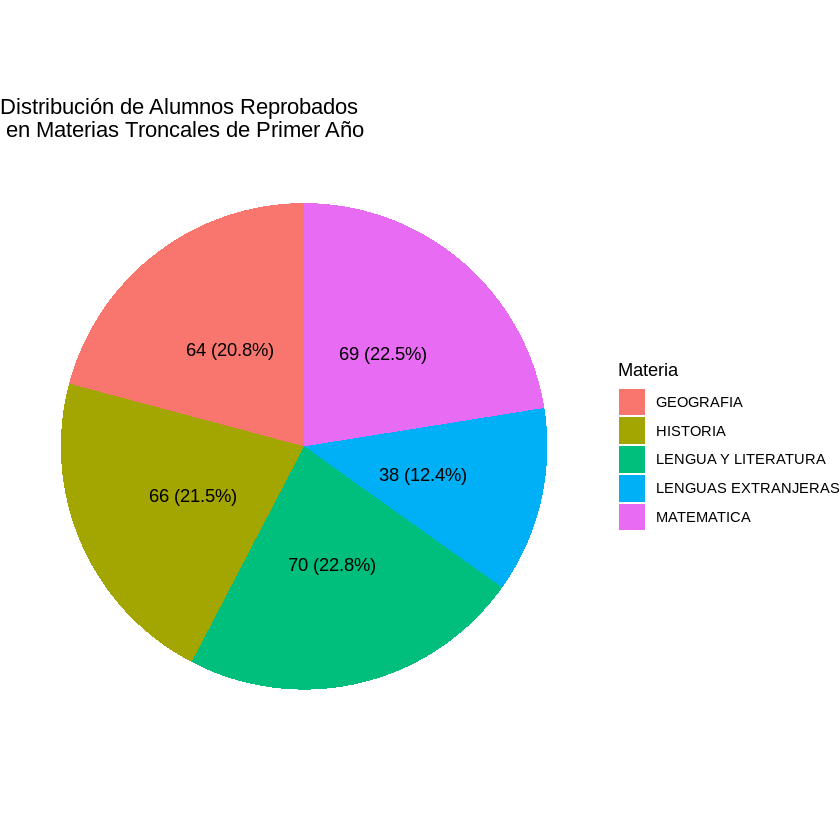

In [ ]:
# prompt: genera un grafico de torta con la cantidad de reprobados por materia en primer año

# Instalar y cargar la librería necesaria
if (!require("ggplot2")) install.packages("ggplot2")
library(ggplot2)

# Filtrar los datos para el primer año
df_primer_año <- df %>% filter(curso == "Año 1 de 3-Secundaria")

# Definir las materias troncales de primer año
materias_troncales_primer_año <- c("MATEMATICA", "LENGUA Y LITERATURA", "HISTORIA", "GEOGRAFIA", "LENGUAS EXTRANJERAS")

# Filtrar por materias troncales y resultados "Reprobado"
df_reprobados_primer_año_troncales <- df_primer_año %>%
  filter(Asignatura %in% materias_troncales_primer_año, resultado_final == "Reprobado")

# Contar la cantidad de reprobados por materia
conteo_reprobados_materia <- df_reprobados_primer_año_troncales %>%
  group_by(Asignatura) %>%
  summarise(Cantidad_Reprobados = n())

# Verificar si hay datos para graficar
if (nrow(conteo_reprobados_materia) == 0) {
  print("No hay datos de alumnos reprobados en materias troncales de primer año para generar el gráfico de torta.")
} else {
  # Calcular las frecuencias relativas para el gráfico de torta
  conteo_reprobados_materia <- conteo_reprobados_materia %>%
    mutate(Frecuencia_Relativa = Cantidad_Reprobados / sum(Cantidad_Reprobados) * 100)

  # Crear el gráfico de torta
  ggplot(conteo_reprobados_materia, aes(x = "", y = Cantidad_Reprobados, fill = Asignatura)) +
    geom_bar(stat = "identity", width = 1) +
    coord_polar("y", start = 0) +
    geom_text(aes(label = paste0(Cantidad_Reprobados, " (", round(Frecuencia_Relativa, 1), "%)")),
              position = position_stack(vjust = 0.5)) +
    labs(title = "Distribución de Alumnos Reprobados \n en Materias Troncales de Primer Año",
         fill = "Materia") +
    theme_void() # Tema vacío para gráfico de torta
}

In [ ]:
library(dplyr)

# Define core subjects
materias_troncales_primer_año <- c("MATEMATICA", "HISTORIA", "LENGUA Y LITERATURA", "GEOGRAFIA", "LENGUAS EXTRANJERAS")

# Filter the dataframe for first year and core subjects
df_primer_año_troncales <- df %>%
  filter(curso == "Año 1 de 3-Secundaria", Asignatura %in% materias_troncales_primer_año)

# Create a contingency table of Asignatura vs. resultado_final (Aprobado/Reprobado)
# Ensure 'resultado_final' only contains 'Aprobado' and 'Reprobado' for this analysis
df_primer_año_troncales_filtered <- df_primer_año_troncales %>%
  filter(resultado_final %in% c("Aprobado", "Reprobado"))

tabla_contingencia_materias <- table(df_primer_año_troncales_filtered$Asignatura, df_primer_año_troncales_filtered$resultado_final)

# Display the contingency table
print("Tabla de Contingencia (Materia vs. Resultado Final - Primer Año):")
print(tabla_contingencia_materias)

# Perform the Chi-squared test
cat("\n--- Resultados del Test de Chi-cuadrado (Materia vs. Resultado Final - Primer Año) ---\n")
chi_test_materias <- chisq.test(tabla_contingencia_materias)

# Print the test results
print(chi_test_materias)

# Optional: Print the residuals to see where the deviations occur
cat("\n--- Residuos del Test de Chi-cuadrado ---\n")
print(round(chi_test_materias$residuals, 2))

# Interpret the results
if (chi_test_materias$p.value < 0.05) {
  print("El test de Chi-cuadrado sugiere que hay una diferencia estadísticamente significativa en la proporción de reprobados entre las materias troncales en el primer año (p < 0.05).")
  print("Examina la tabla de contingencia y los residuos para identificar qué materias contribuyen a esta diferencia.")
} else {
  print("El test de Chi-cuadrado no sugiere una diferencia estadísticamente significativa en la proporción de reprobados entre las materias troncales en el primer año (p >= 0.05).")
}

[1] "Tabla de Contingencia (Materia vs. Resultado Final - Primer Año):"
                     
                      Aprobado Reprobado
  GEOGRAFIA                 40        64
  HISTORIA                  39        66
  LENGUA Y LITERATURA       36        70
  LENGUAS EXTRANJERAS       41        38
  MATEMATICA                37        69

--- Resultados del Test de Chi-cuadrado (Materia vs. Resultado Final - Primer Año) ---

	Pearson's Chi-squared test

data:  tabla_contingencia_materias
X-squared = 7.5624, df = 4, p-value = 0.109


--- Residuos del Test de Chi-cuadrado ---
                     
                      Aprobado Reprobado
  GEOGRAFIA              -0.02      0.02
  HISTORIA               -0.24      0.19
  LENGUA Y LITERATURA    -0.77      0.61
  LENGUAS EXTRANJERAS     1.90     -1.51
  MATEMATICA             -0.61      0.49
[1] "El test de Chi-cuadrado no sugiere una diferencia estadísticamente significativa en la proporción de reprobados entre las materias troncales en el

`summarise()` has grouped output by 'curso'. You can override using the
`.groups` argument.
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


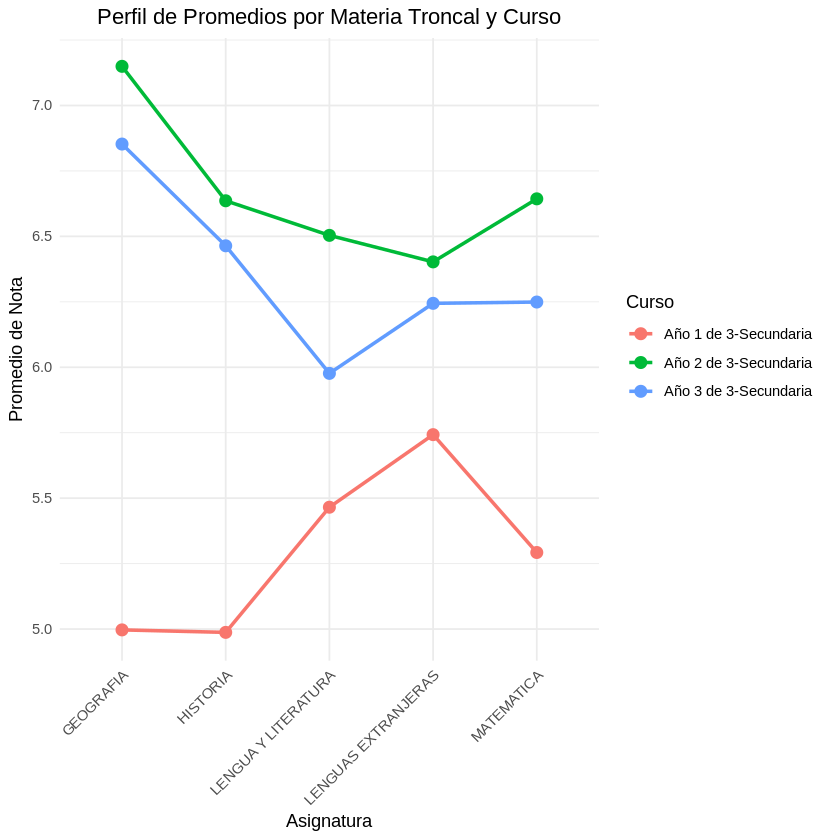

In [ ]:
# prompt: quiero un grafico de perfiles por curso que me muestre el promedio de cada materia troncal en cada uno de los cursos el grafico tiene que tener los promedios de los 3 cursos incluidos

library(dplyr)
library(ggplot2)
library(tidyr) # For pivot_longer

# Define core subjects for the profile plot
materias_troncales_perfil <- c("MATEMATICA", "LENGUA Y LITERATURA", "HISTORIA", "GEOGRAFIA", "LENGUAS EXTRANJERAS")

# Filter data for core subjects
df_troncales_perfil <- df %>%
  filter(Asignatura %in% materias_troncales_perfil)

# Calculate the mean average for each subject and course
df_promedio_por_curso_materia <- df_troncales_perfil %>%
  group_by(curso, Asignatura) %>%
  summarise(Promedio_Materia = mean(Promedio, na.rm = TRUE)) %>% # Calculate mean, ignoring NAs
  ungroup()

# Reshape the data for the profile plot (wide to long format)
df_promedio_long <- df_promedio_por_curso_materia %>%
  pivot_longer(cols = Promedio_Materia,
               names_to = "Metrica",
               values_to = "Valor_Promedio")

# Create the profile plot
ggplot(df_promedio_long, aes(x = Asignatura, y = Valor_Promedio, color = curso, group = curso)) +
  geom_line(size = 1) +
  geom_point(size = 3) +
  labs(title = "Perfil de Promedios por Materia Troncal y Curso",
       x = "Asignatura",
       y = "Promedio de Nota",
       color = "Curso") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), # Rotate x-axis labels for readability
        plot.title = element_text(hjust = 0.5)) # Center the title

In [ ]:
library(dplyr)
library(car) # For Levene's test (optional but recommended)
library(ggplot2) # For visualizations (optional)

# Ensure 'df' is available and contains the necessary columns
if (!exists("df") || !is.data.frame(df)) {
  stop("El dataframe 'df' no existe.")
}

# Define core subjects
materias_troncales <- c("MATEMATICA", "HISTORIA")

# Filter the dataframe for core subjects
df_troncales <- df %>%
  filter(Asignatura %in% materias_troncales)

# Perform ANOVA for each core subject
for (materia in materias_troncales) {
  cat("\n--- ANOVA para", materia, "---\n")

  # Filter data for the current subject
  df_materia <- df_troncales %>%
    filter(Asignatura == materia)

  # Check if there is enough data for ANOVA
  if (nrow(df_materia) < 3 || length(unique(df_materia$curso)) < 2) {
    print(paste("No hay suficientes datos para realizar ANOVA para", materia))
    next
  }

  # Perform the one-way ANOVA test
  anova_result <- aov(Promedio ~ curso, data = df_materia)

  # Print the ANOVA summary
  print(summary(anova_result))

  # Optional: Perform Tukey's HSD post-hoc test if ANOVA is significant
  # This helps identify which specific year pairs have significant differences
  anova_summary <- summary(anova_result)
  if (anova_summary[[1]]$`Pr(>F)`[1] < 0.05) {
    cat("\n--- Post-hoc Tukey HSD test para", materia, "---\n")
    tukey_result <- TukeyHSD(anova_result)
    print(tukey_result)
  }
}


--- ANOVA para MATEMATICA ---
             Df Sum Sq Mean Sq F value   Pr(>F)    
curso         2   94.9   47.47   12.12 8.81e-06 ***
Residuals   292 1144.0    3.92                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- Post-hoc Tukey HSD test para MATEMATICA ---
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Promedio ~ curso, data = df_materia)

$curso
                                                  diff        lwr       upr
Año 2 de 3-Secundaria-Año 1 de 3-Secundaria  1.3509580  0.6742456 2.0276705
Año 3 de 3-Secundaria-Año 1 de 3-Secundaria  0.9567381  0.3115932 1.6018830
Año 3 de 3-Secundaria-Año 2 de 3-Secundaria -0.3942199 -1.0753323 0.2868924
                                                p adj
Año 2 de 3-Secundaria-Año 1 de 3-Secundaria 0.0000118
Año 3 de 3-Secundaria-Año 1 de 3-Secundaria 0.0015921
Año 3 de 3-Secundaria-Año 2 de 3-Secundaria 0.3615120


--- ANOVA para HISTORIA ---
       

In [ ]:
install.packages("nortest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(dplyr)
# library(nortest) # Ya no es necesaria solo para Shapiro-Wilk

# Aseguráte de que 'df' exista y sea un dataframe.
# Si 'df' no está cargado, este script se detendrá.
if (!exists("df") || !is.data.frame(df)) {
  stop("El dataframe 'df' no existe. Por favor, asegurate de cargarlo antes de ejecutar el script.")
}

# Definimos las materias troncales
materias_troncales <- c("MATEMATICA", "HISTORIA")

# Filtramos el dataframe para estas materias
df_troncales <- df %>% filter(Asignatura %in% materias_troncales)

# Iteramos sobre cada materia troncal
for (materia in materias_troncales) {
  cat("\n--- Análisis para", materia, "---\n")

  # Filtramos los datos para la materia actual
  df_materia <- df_troncales %>% filter(Asignatura == materia)

  # Verificamos que haya suficientes datos para realizar el ANOVA
  if (nrow(df_materia) < 3 || length(unique(df_materia$curso)) < 2) {
    message(paste("Advertencia: No hay suficientes datos (menos de 3 filas o menos de 2 cursos) para realizar el ANOVA para", materia))
    next
  }

  # Convertimos 'curso' a factor para que ANOVA lo trate como una variable categórica
  df_materia$curso <- as.factor(df_materia$curso)

  # 1. Aplicamos el Test de ANOVA
  # Esto nos da el modelo del cual extraeremos los residuos.
  cat("\n--- Resultados del ANOVA para", materia, "---\n")
  anova_result <- aov(Promedio ~ curso, data = df_materia)
  print(summary(anova_result))

  # 2. Extraemos los residuos del modelo ANOVA
  residuos <- residuals(anova_result)

  # 3. Comprobamos la Normalidad de los Residuos (Test de Shapiro-Wilk)
  # H0: Los residuos siguen una distribución normal
  # H1: Los residuos no siguen una distribución normal
  cat("\n--- Prueba de Normalidad de los Residuos (Test de Shapiro-Wilk) para", materia, "---\n")
  shapiro_test <- shapiro.test(residuos)
  print(shapiro_test)

  # Interpretación básica del resultado de la normalidad
  if (shapiro_test$p.value < 0.05) {
    message("Advertencia: Los residuos NO parecen seguir una distribución normal (p < 0.05).")
  } else {
    message("Los residuos parecen seguir una distribución normal (p >= 0.05).")
  }
}




--- Análisis para MATEMATICA ---

--- Resultados del ANOVA para MATEMATICA ---
             Df Sum Sq Mean Sq F value   Pr(>F)    
curso         2   94.9   47.47   12.12 8.81e-06 ***
Residuals   292 1144.0    3.92                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- Prueba de Normalidad de los Residuos (Test de Shapiro-Wilk) para MATEMATICA ---

	Shapiro-Wilk normality test

data:  residuos
W = 0.94832, p-value = 1.128e-08



Advertencia: Los residuos NO parecen seguir una distribución normal (p < 0.05).




--- Análisis para HISTORIA ---

--- Resultados del ANOVA para HISTORIA ---
             Df Sum Sq Mean Sq F value   Pr(>F)    
curso         2  164.8   82.40   15.57 3.76e-07 ***
Residuals   291 1539.9    5.29                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- Prueba de Normalidad de los Residuos (Test de Shapiro-Wilk) para HISTORIA ---

	Shapiro-Wilk normality test

data:  residuos
W = 0.95994, p-value = 3.078e-07



Advertencia: Los residuos NO parecen seguir una distribución normal (p < 0.05).



In [ ]:
library(dplyr)
library(car) # Para la función TukeyHSD

# Asegúrate de que 'df' exista y sea un dataframe.
if (!exists("df") || !is.data.frame(df)) {
  stop("El dataframe 'df' no existe. Por favor, asegúrate de cargarlo antes de ejecutar el script.")
}

# Definimos las materias troncales
materias_troncales <- c("MATEMATICA", "HISTORIA")

# Filtramos el dataframe para estas materias
df_troncales <- df %>% filter(Asignatura %in% materias_troncales)

# Iteramos sobre cada materia troncal
for (materia in materias_troncales) {
  cat("\n--- Análisis para", materia, "---\n")

  # Filtramos los datos para la materia actual
  df_materia <- df_troncales %>% filter(Asignatura == materia)

  # Verificamos que haya suficientes datos para los tests
  if (nrow(df_materia) < 3 || length(unique(df_materia$curso)) < 2) {
    message(paste("No hay suficientes datos (menos de 3 filas o menos de 2 cursos) para realizar los tests para", materia))
    next
  }

  # Convertimos 'curso' a factor para que los tests lo traten como una variable categórica
  df_materia$curso <- as.factor(df_materia$curso)

  # --- Resultados del Test de Kruskal-Wallis ---
  cat("\n--- Resultados del Test de Kruskal-Wallis para", materia, "---\n")
  kruskal_result <- kruskal.test(Promedio ~ curso, data = df_materia)
  print(kruskal_result)


}


--- Análisis para MATEMATICA ---

--- Resultados del Test de Kruskal-Wallis para MATEMATICA ---

	Kruskal-Wallis rank sum test

data:  Promedio by curso
Kruskal-Wallis chi-squared = 24.726, df = 2, p-value = 4.274e-06


--- Análisis para HISTORIA ---

--- Resultados del Test de Kruskal-Wallis para HISTORIA ---

	Kruskal-Wallis rank sum test

data:  Promedio by curso
Kruskal-Wallis chi-squared = 27.122, df = 2, p-value = 1.29e-06



In [ ]:
# prompt: aplicame Test de Mann-Whitney U con corrección de p-values para los cursos que compare en kruskal y me dieron diferencias significativas es decir haslo a modo de post hoc

library(dplyr)
library(rstatix) # Para la función pairwise_wilcox_test
library(ggplot2) # Opcional, para visualización

# Asegúrate de que 'df' exista y sea un dataframe.
if (!exists("df") || !is.data.frame(df)) {
  stop("El dataframe 'df' no existe. Por favor, asegúrate de cargarlo antes de ejecutar el script.")
}

# Define las materias troncales para las que se realizó Kruskal-Wallis y dio significativo
# Basado en el código anterior, asumimos que MATEMATICA e HISTORIA fueron significativas.
materias_significativas <- c("MATEMATICA", "HISTORIA")

# Filtramos el dataframe para estas materias
df_significativas <- df %>% filter(Asignatura %in% materias_significativas)

# Iteramos sobre cada materia significativa para realizar el post-hoc
for (materia in materias_significativas) {
  cat("\n--- Post-hoc (Test de Mann-Whitney U con corrección) para", materia, "---\n")

  # Filtramos los datos para la materia actual
  df_materia <- df_significativas %>% filter(Asignatura == materia)

  # Verificamos que haya al menos dos grupos de cursos con datos para esta materia
  if (length(unique(df_materia$curso)) < 2) {
    message(paste("No hay suficientes grupos de cursos (menos de 2) para realizar el post-hoc para", materia))
    next
  }

  # Realiza el test de Mann-Whitney U (pairwise Wilcoxon test) para cada par de cursos.
  # Se aplica automáticamente una corrección de p-value (por defecto, Holm)
  post_hoc_result <- df_materia %>%
    pairwise_wilcox_test(Promedio ~ curso, p.adjust.method = "BH") # Usamos Benjamini-Hochberg (BH)

  # Imprime los resultados del post-hoc
  print(post_hoc_result)

  # Interpretación básica de los resultados del post-hoc
  # Las filas con p.adj < 0.05 indican pares de grupos (cursos) con diferencias significativas
  # en la distribución de sus promedios según el test de Mann-Whitney U.
  signif_pairs <- post_hoc_result %>% filter(p.adj < 0.05)

  if (nrow(signif_pairs) > 0) {
    cat("Pares de cursos con diferencias significativas en", materia, " (p.adj < 0.05):\n")
    print(signif_pairs)
  } else {
    cat("No se encontraron pares de cursos con diferencias significativas en", materia, "después de la corrección de p-values.\n")
  }
}



Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter





--- Post-hoc (Test de Mann-Whitney U con corrección) para MATEMATICA ---
# A tibble: 3 × 9
  .y.      group1      group2    n1    n2 statistic       p   p.adj p.adj.signif
* <chr>    <chr>       <chr>  <int> <int>     <dbl>   <dbl>   <dbl> <chr>       
1 Promedio Año 1 de 3… Año 2…   106    86     2830. 5   e-6 1.5 e-5 ****        
2 Promedio Año 1 de 3… Año 3…   106   103     3790  1.2 e-4 1.8 e-4 ***         
3 Promedio Año 2 de 3… Año 3…    86   103     4874. 2.35e-1 2.35e-1 ns          
Pares de cursos con diferencias significativas en MATEMATICA  (p.adj < 0.05):
# A tibble: 2 × 9
  .y.      group1        group2    n1    n2 statistic      p  p.adj p.adj.signif
  <chr>    <chr>         <chr>  <int> <int>     <dbl>  <dbl>  <dbl> <chr>       
1 Promedio Año 1 de 3-S… Año 2…   106    86     2830. 5  e-6 1.5e-5 ****        
2 Promedio Año 1 de 3-S… Año 3…   106   103     3790  1.2e-4 1.8e-4 ***         

--- Post-hoc (Test de Mann-Whitney U con corrección) para HISTORIA ---
# A tibble: